In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.stats as st

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [2]:
summary_gapfill_betaine = pd.read_csv('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_1plex_summary.csv', index_col=0)


85
SignificanceResult(statistic=0.48365109942675166, pvalue=2.7452469526523615e-06)


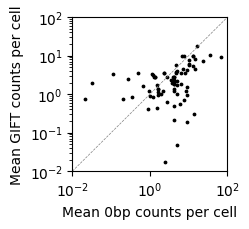

In [3]:
df = summary_gapfill_betaine[['mean_counts','mean_0bp_count']].dropna()

fig,ax = plt.subplots(figsize=(2,2))
ax.scatter(df['mean_0bp_count'], df['mean_counts'], s=3, color='black')

ax.set_xlabel('Mean 0bp counts per cell')
ax.set_ylabel('Mean GIFT counts per cell')

ax.set_xscale('log')
ax.set_yscale('log')

xmin = 0.01
xmax = 100
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)

x = np.array(ax.get_xlim())
ax.plot(x, x, linestyle='--', color='grey', linewidth=0.5)

print(len(df['mean_0bp_count']))
print(st.spearmanr(df['mean_0bp_count'], df['mean_counts']))

plt.savefig('../plots/GIFT_vs_WTA_counts.pdf', bbox_inches='tight')

In [4]:
## get efficiency measure
(summary_gapfill_betaine['mean_counts'] / summary_gapfill_betaine['mean_0bp_count']).dropna().median()

0.5941101152368758

In [5]:
## get number of datapoints
len(summary_gapfill_betaine)

95